**An end-to-end data science project analyzing transaction dynamics across consumer gaming cards and enterprise AI accelerators. The pipeline covers robust data ingestion, automated cleaning, feature engineering, exploratory visual analysis, an XGBoost predictive revenue model, and structured dataset exports for Tableau dashboarding.**

### Business Problems:

The hardware graphics and AI accelerator market faces structural volatility across supply chains, distribution channels, and regional customer segments. This project addresses three primary business questions:

* Supply Chain Premium Capture: How severely do regional stock shortages inflate secondary market street prices over MSRP, and how can pricing strategies capture this lost margin?
* Channel & Segment Yield Analysis: Which sales channels (System Integrators, Direct-to-Consumer, Retail) and customer segments (Hyperscale Datacenters vs. Gaming) yield the highest per-unit revenue realization?
* Predictive Revenue Modeling: Can machine learning accurately predict order-level revenue based on product age, regional channel parameters, and pricing spread without relying on target-derived features?

## 1. Environment Setup & Data Cleaning 

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter


plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

sns.set_theme(style='whitegrid')
sns.set_palette('mako')

df = None
dataset_slug = "muhammadhuzaifagohar/nvidia-gpu-sales-data-2026"
file_name = "nvidia_gpu_sales_synthetic_2026.csv"

local_files = glob.glob(f"/kaggle/input/**/{file_name}", recursive=True) + glob.glob("/kaggle/input/**/*.csv", recursive=True)
if local_files:
    df = pd.read_csv(local_files[0])

df.head()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,1796.91,12.38,Low Stock,4.0,12,Software Bundle,14375.30
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.0,12,NaN,32799.82
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,1308.25,30.96,Sold Out,4.0,12,NaN,39247.64
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,29202.11,8.16,Low Stock,4.5,24,NaN,146010.54
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,27778.73,2.88,In Stock,4.5,36,NaN,250008.56


## 2.Data Cleaning & Type Conversion

In [2]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

col_map = {c: c for c in df.columns}
for c in df.columns:
    if 'date' in c:
        col_map[c] = 'sale_date'
    elif 'revenue' in c:
        col_map[c] = 'revenue_usd'
    elif 'units' in c:
        col_map[c] = 'units_sold'
    elif 'warranty' in c:
        col_map[c] = 'warranty_months'
    elif 'bundle' in c:
        col_map[c] = 'bundle_accessory'
    elif 'launch' in c:
        col_map[c] = 'launch_year'
    elif 'msrp' in c:
        col_map[c] = 'msrp_usd'
    elif 'street' in c:
        col_map[c] = 'avg_street_price_usd'
    elif 'premium' in c:
        col_map[c] = 'price_premium_pct'
    elif 'stock' in c:
        col_map[c] = 'stock_status'

df = df.rename(columns=col_map)

# Safely parse date column
if 'sale_date' in df.columns:
    df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
    df = df.dropna(subset=['sale_date'])

# Handle missing numeric and categorical columns safely
if 'warranty_months' in df.columns:
    df['warranty_months'] = pd.to_numeric(df['warranty_months'], errors='coerce')
    df['warranty_months'] = df['warranty_months'].fillna(df['warranty_months'].median()).astype(int)

if 'bundle_accessory' in df.columns:
    df['bundle_accessory'] = df['bundle_accessory'].fillna('None').astype(str)

if 'launch_year' in df.columns:
    df['launch_year'] = pd.to_numeric(df['launch_year'], errors='coerce').fillna(2022).astype(int)

if 'units_sold' in df.columns:
    df['units_sold'] = pd.to_numeric(df['units_sold'], errors='coerce').fillna(1).astype(int)

if 'revenue_usd' in df.columns:
    df['revenue_usd'] = pd.to_numeric(df['revenue_usd'], errors='coerce')
    df = df.dropna(subset=['revenue_usd'])

# Row-level validation
if 'units_sold' in df.columns and 'revenue_usd' in df.columns:
    df = df[(df['units_sold'] > 0) & (df['revenue_usd'] >= 0)].copy()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   sale_id                      7000 non-null   int64         
 1   sale_date                    7000 non-null   datetime64[ns]
 2   gpu_model                    7000 non-null   object        
 3   gpu_family                   7000 non-null   object        
 4   launch_year                  7000 non-null   int64         
 5   region                       7000 non-null   object        
 6   sales_channel                7000 non-null   object        
 7   customer_segment             7000 non-null   object        
 8   units_sold                   7000 non-null   int64         
 9   msrp_usd                     7000 non-null   int64         
 10  avg_street_price_usd         7000 non-null   float64       
 11  price_premium_pct            7000 non-null 

## 3. Exploratory Data Analysis & Visualizations 

/tmp/ipykernel_16/2072217452.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


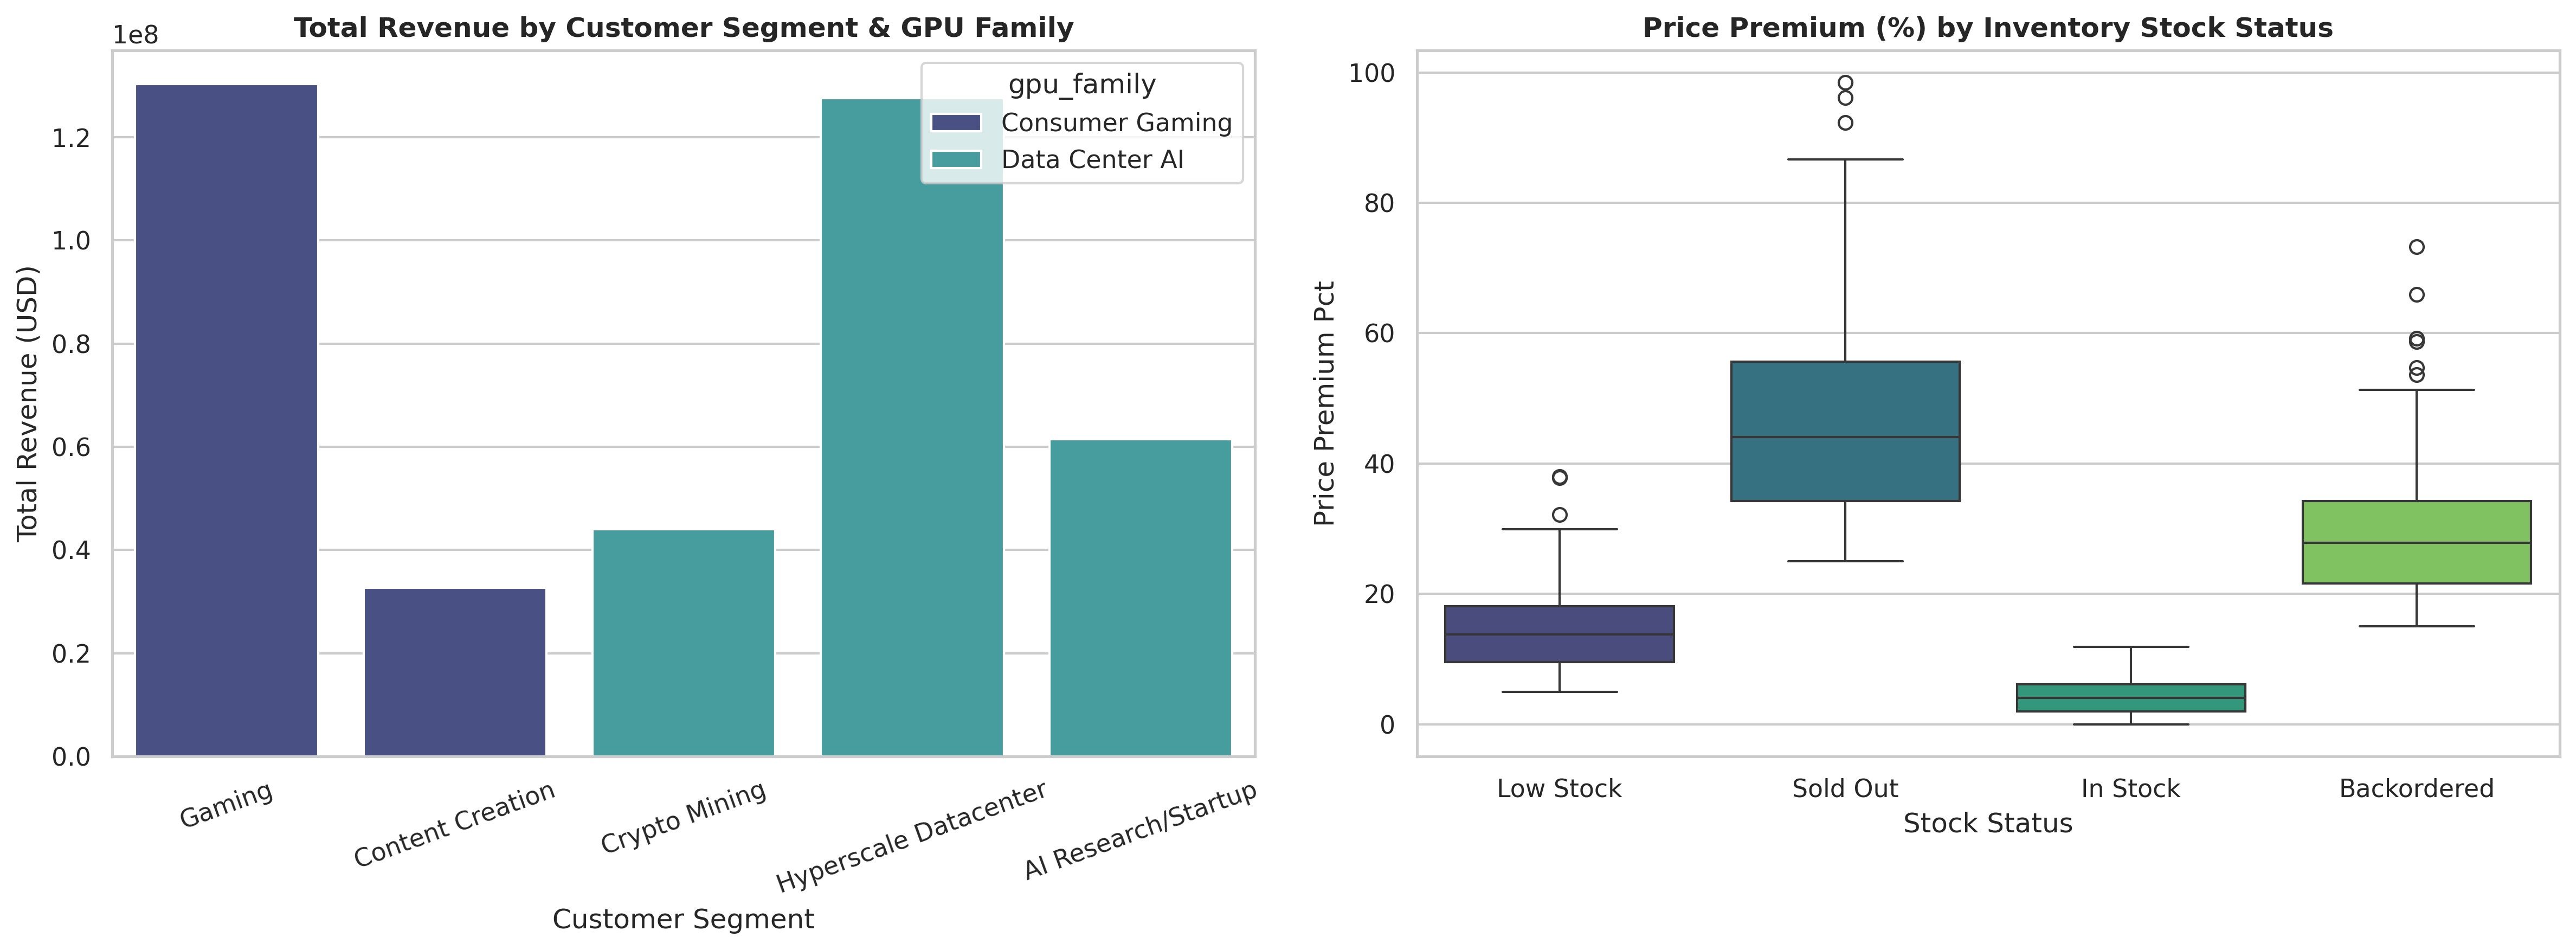

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total Revenue by Customer Segment & GPU Family
cat_segment = 'customer_segment' if 'customer_segment' in df.columns else df.select_dtypes(include='object').columns[0]
hue_family = 'gpu_family' if 'gpu_family' in df.columns else df.select_dtypes(include='object').columns[1]

sns.barplot(
    data=df,
    x=cat_segment,
    y='revenue_usd',
    hue=hue_family,
    estimator=np.sum,
    errorbar=None,
    ax=axes[0],
    palette='mako'
)
axes[0].set_title('Total Revenue by Customer Segment & GPU Family', fontweight='bold')
axes[0].set_xlabel(cat_segment.replace('_', ' ').title())
axes[0].set_ylabel('Total Revenue (USD)')
axes[0].tick_params(axis='x', rotation=20)

stock_col = 'stock_status' if 'stock_status' in df.columns else cat_segment
prem_col = 'price_premium_pct' if 'price_premium_pct' in df.columns else 'revenue_usd'

sns.boxplot(
    data=df,
    x=stock_col,
    y=prem_col,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Price Premium (%) by Inventory Stock Status', fontweight='bold')
axes[1].set_xlabel(stock_col.replace('_', ' ').title())
axes[1].set_ylabel(prem_col.replace('_', ' ').title())

plt.tight_layout()
plt.show()

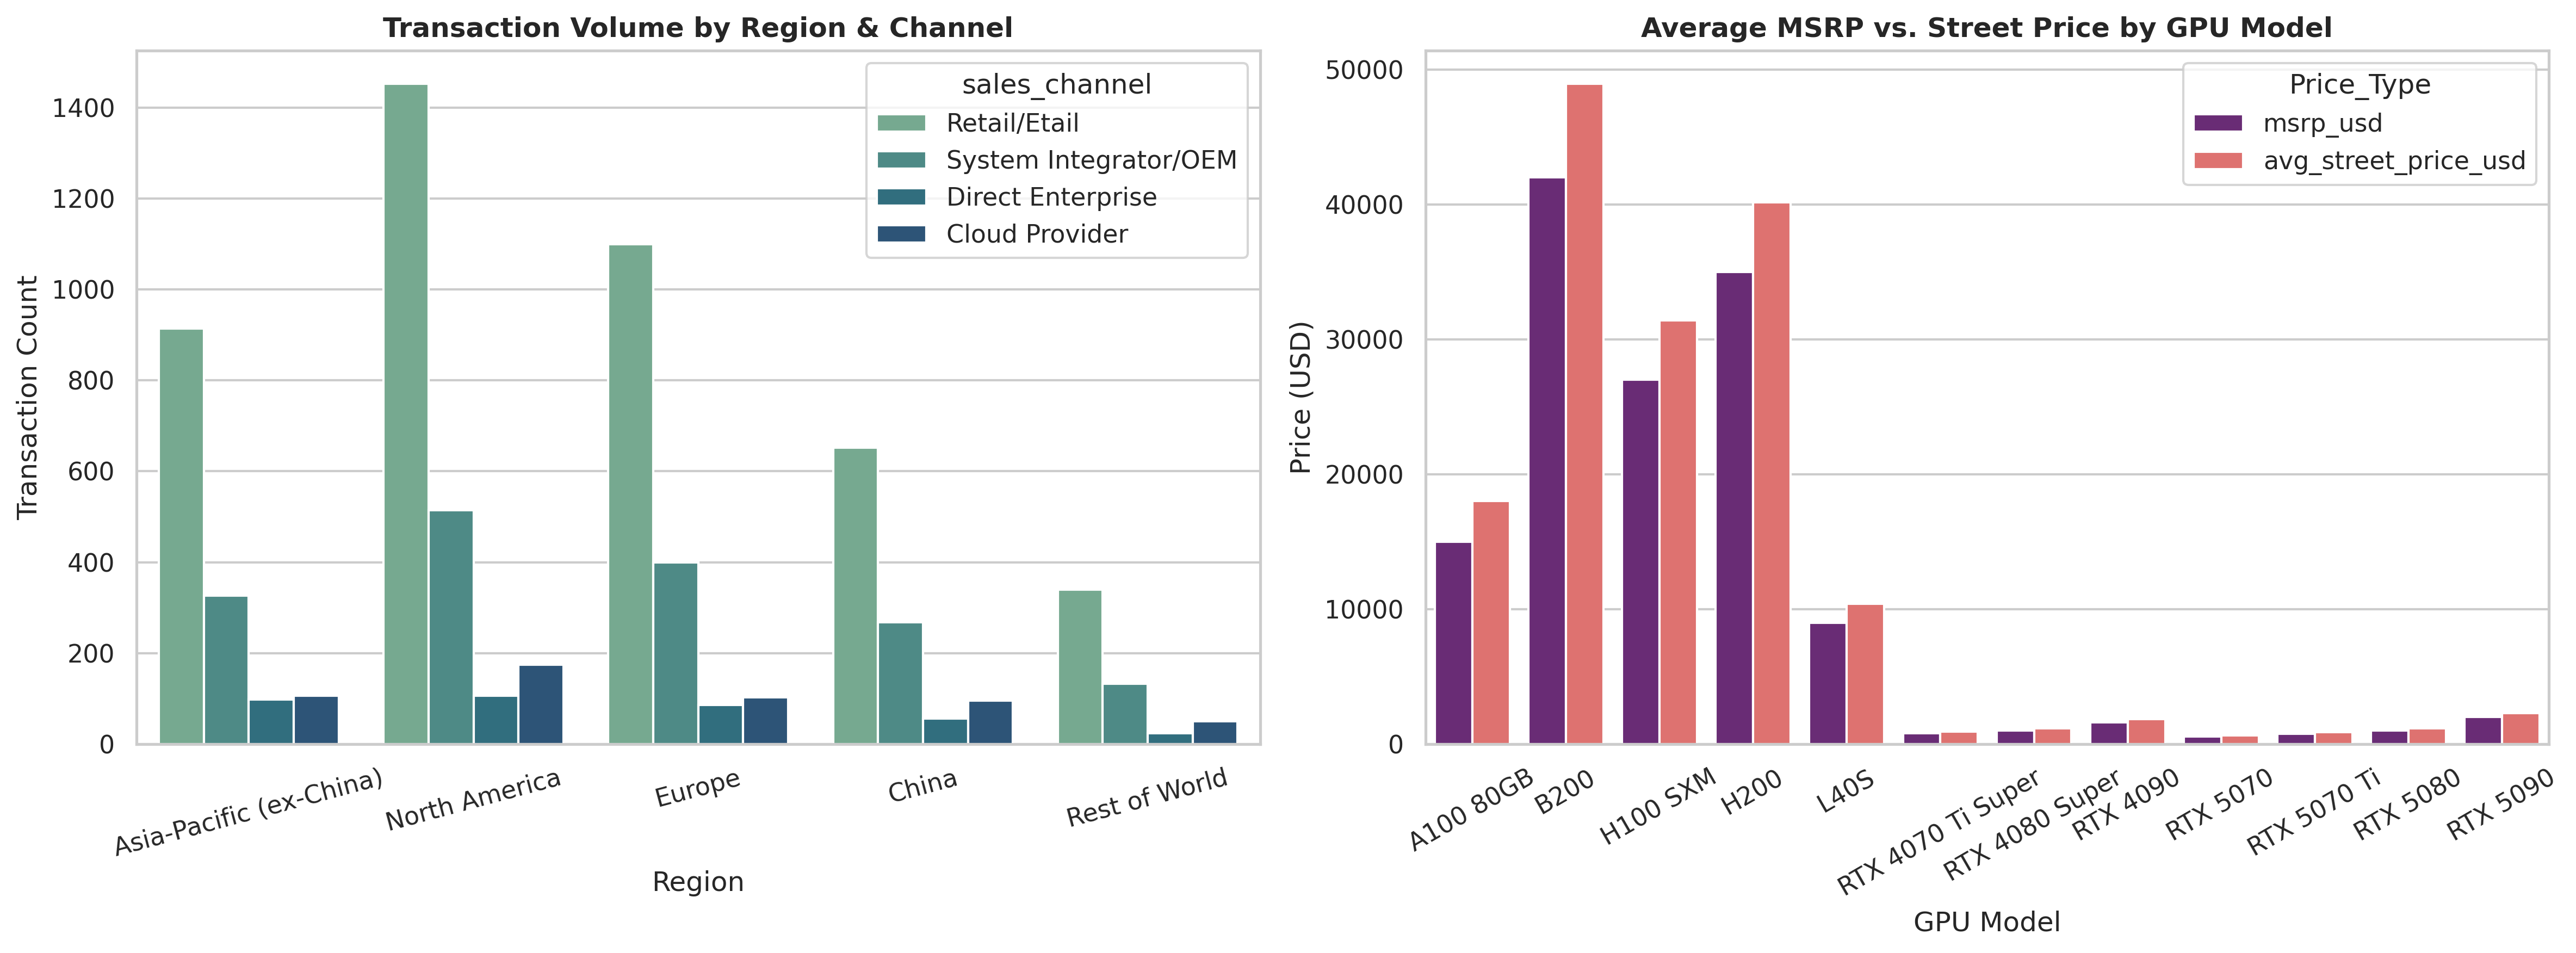

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales Channel vs Region Breakdown
region_col = 'region' if 'region' in df.columns else cat_segment
channel_col = 'sales_channel' if 'sales_channel' in df.columns else hue_family

sns.countplot(
    data=df,
    x=region_col,
    hue=channel_col,
    ax=axes[0],
    palette='crest'
)
axes[0].set_title('Transaction Volume by Region & Channel', fontweight='bold')
axes[0].set_xlabel(region_col.replace('_', ' ').title())
axes[0].set_ylabel('Transaction Count')
axes[0].tick_params(axis='x', rotation=15)

# Price Dynamics: MSRP vs Street Price
model_col = 'gpu_model' if 'gpu_model' in df.columns else cat_segment
if 'msrp_usd' in df.columns and 'avg_street_price_usd' in df.columns:
    price_df = df.groupby(model_col)[['msrp_usd', 'avg_street_price_usd']].mean().reset_index()
    price_melted = price_df.melt(id_vars=model_col, value_vars=['msrp_usd', 'avg_street_price_usd'],
                                  var_name='Price_Type', value_name='Price_USD')

    sns.barplot(
        data=price_melted,
        x=model_col,
        y='Price_USD',
        hue='Price_Type',
        ax=axes[1],
        palette='magma'
    )
    axes[1].set_title('Average MSRP vs. Street Price by GPU Model', fontweight='bold')
    axes[1].set_xlabel('GPU Model')
    axes[1].set_ylabel('Price (USD)')
    axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Robust Feature Engineering Pipeline

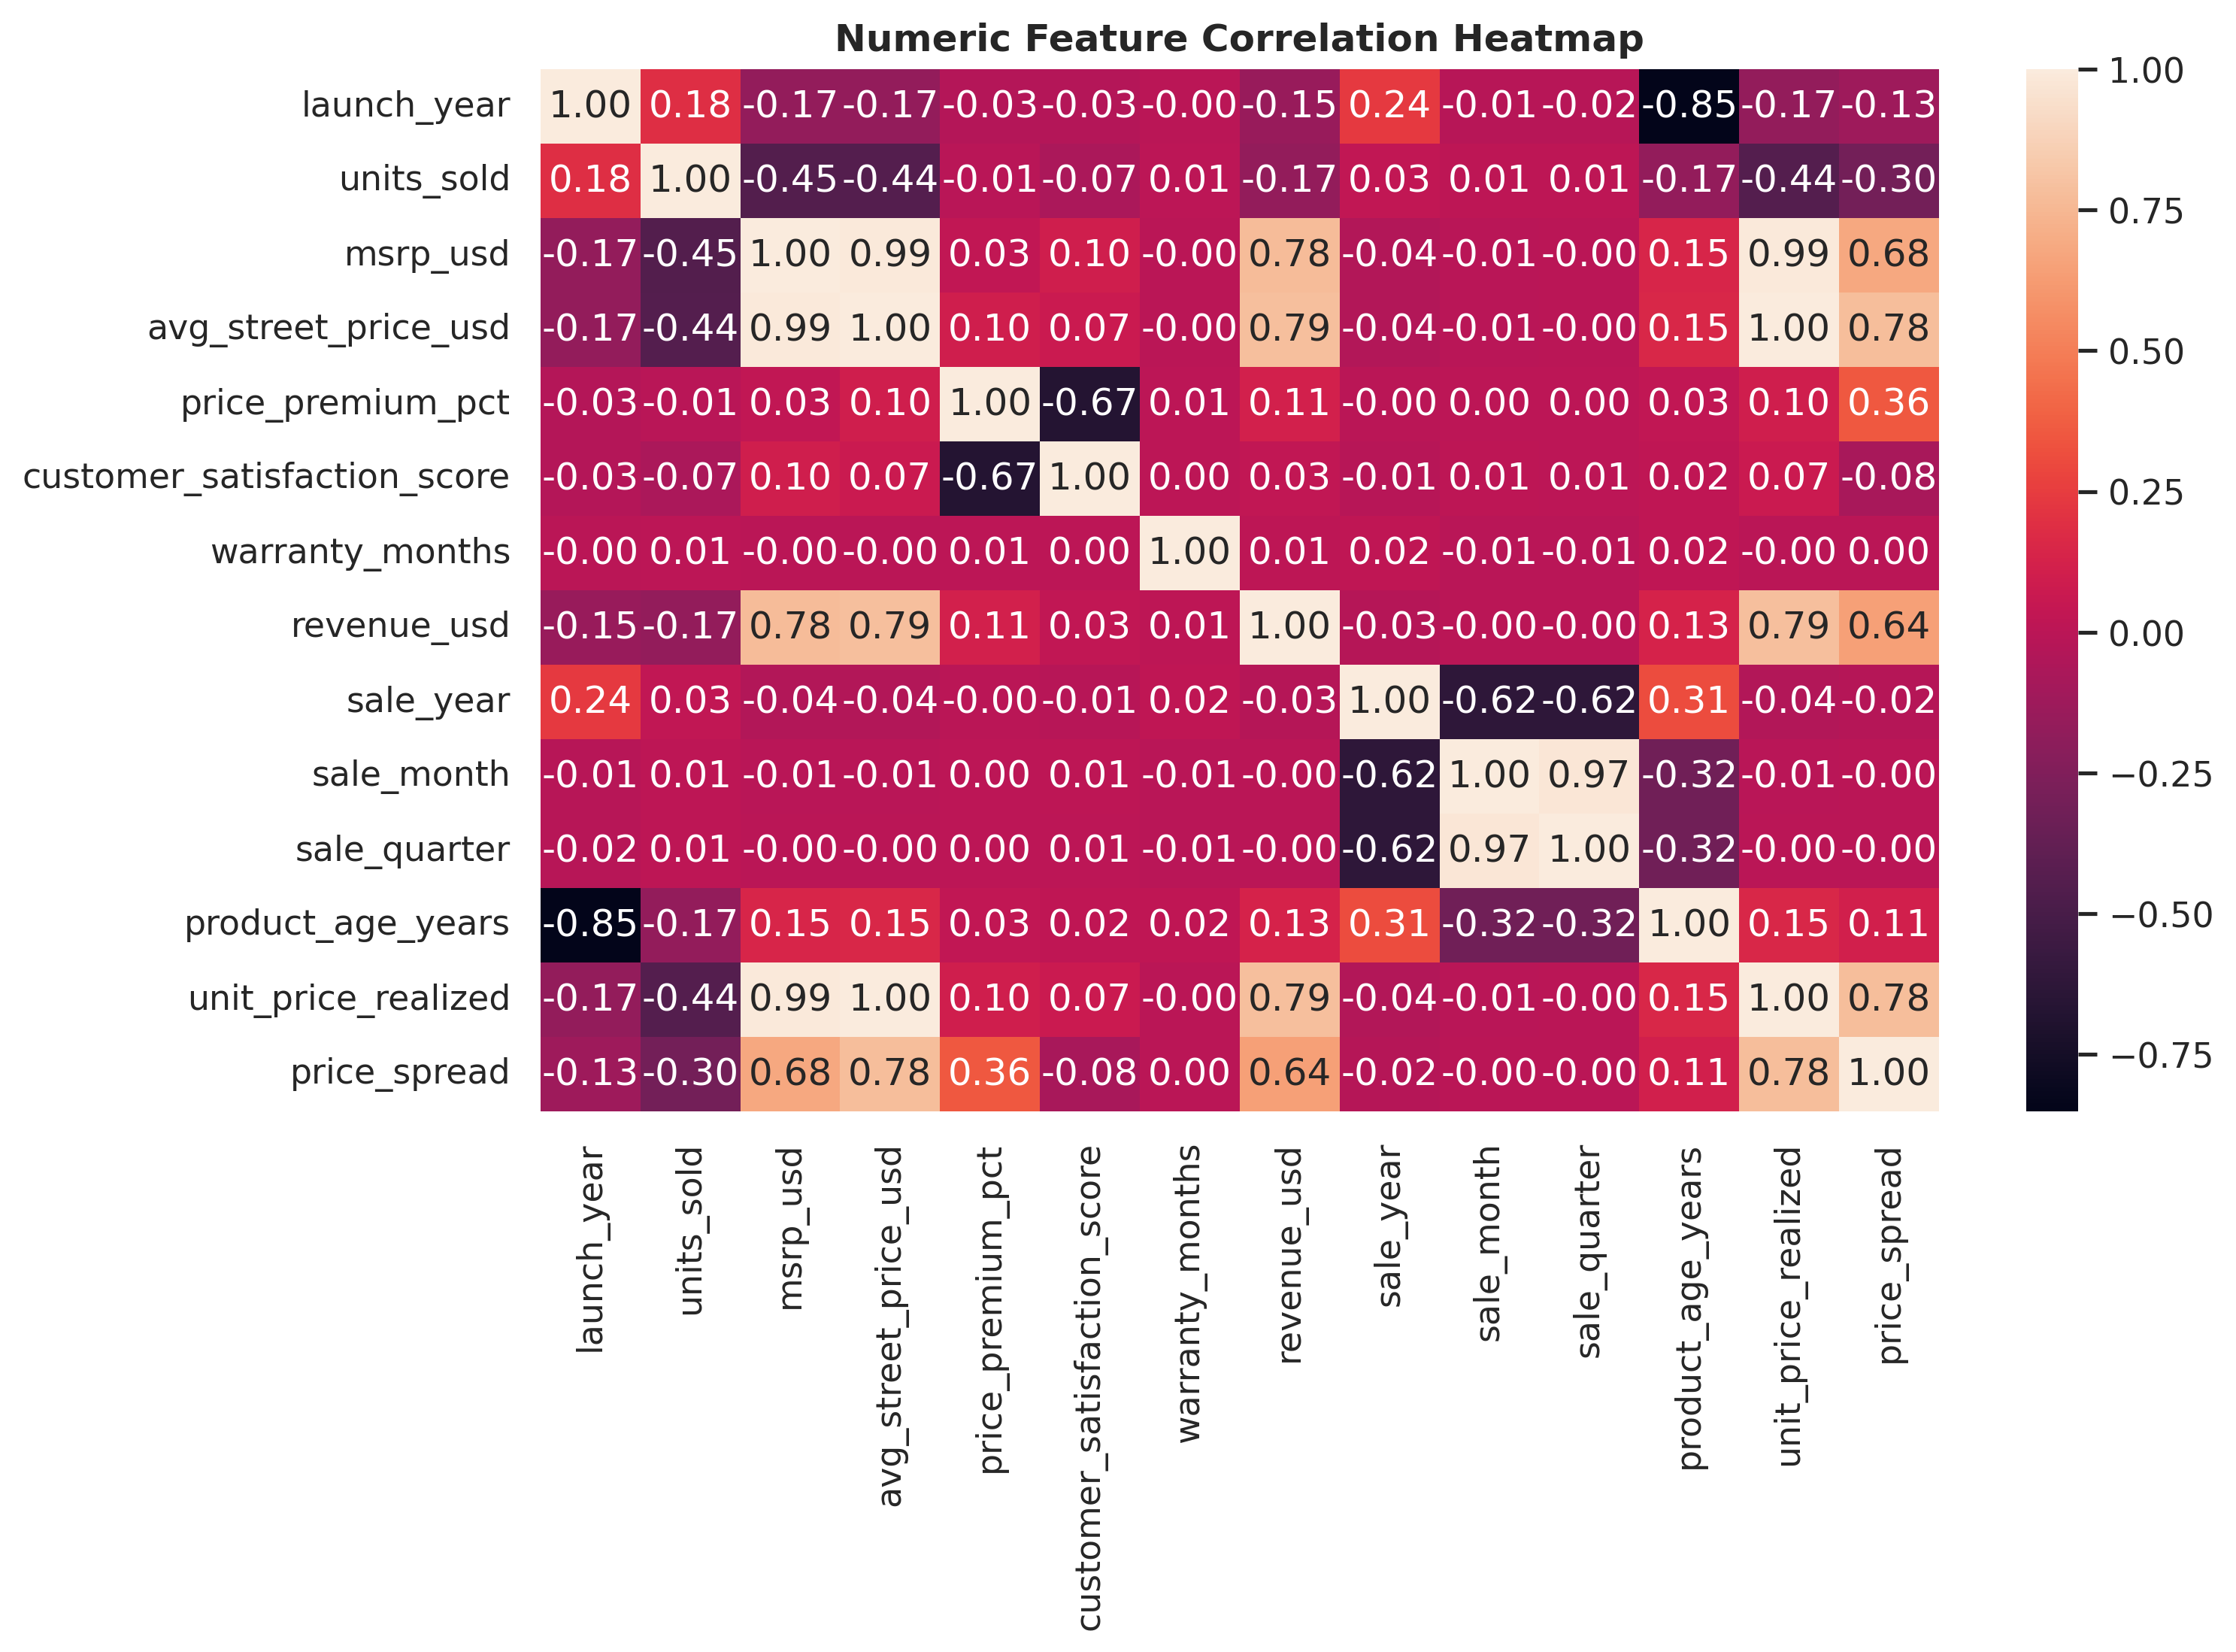

In [5]:
# Extract temporal features safely
if 'sale_date' in df.columns:
    df['sale_year'] = df['sale_date'].dt.year
    df['sale_month'] = df['sale_date'].dt.month
    df['sale_quarter'] = df['sale_date'].dt.quarter

if 'sale_year' in df.columns and 'launch_year' in df.columns:
    df['product_age_years'] = (df['sale_year'] - df['launch_year']).clip(lower=0)

# Derived business ratios
if 'units_sold' in df.columns and 'revenue_usd' in df.columns:
    df['unit_price_realized'] = df['revenue_usd'] / df['units_sold']

if 'avg_street_price_usd' in df.columns and 'msrp_usd' in df.columns:
    df['price_spread'] = df['avg_street_price_usd'] - df['msrp_usd']

# Plot Correlation Matrix for Numeric Features
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['sale_id'], errors='ignore')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='rocket', cbar=True)
plt.title('Numeric Feature Correlation Heatmap', fontweight='bold')
plt.show()

## 5. Machine Learning Pipeline & Evaluation

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# Select features excluding direct revenue target leaks
potential_features = [
    'gpu_model', 'gpu_family', 'region', 'sales_channel', 
    'customer_segment', 'units_sold', 'msrp_usd', 
    'avg_street_price_usd', 'price_premium_pct', 'stock_status', 
    'warranty_months', 'bundle_accessory', 'product_age_years', 
    'sale_month', 'sale_quarter'
]

features = [col for col in potential_features if col in df.columns]

X = df[features].copy()
y = df['revenue_usd'].copy()

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.04,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

# Metrics calculation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"--- XGBoost Model Performance ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE: ${mae:,.2f}")

--- XGBoost Model Performance ---
R² Score: 0.9981
RMSE: $3,909.13
MAE: $1,157.94


## 6. Feature Importance Analysis

/tmp/ipykernel_16/411886452.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='importance', y='feature', palette='mako')


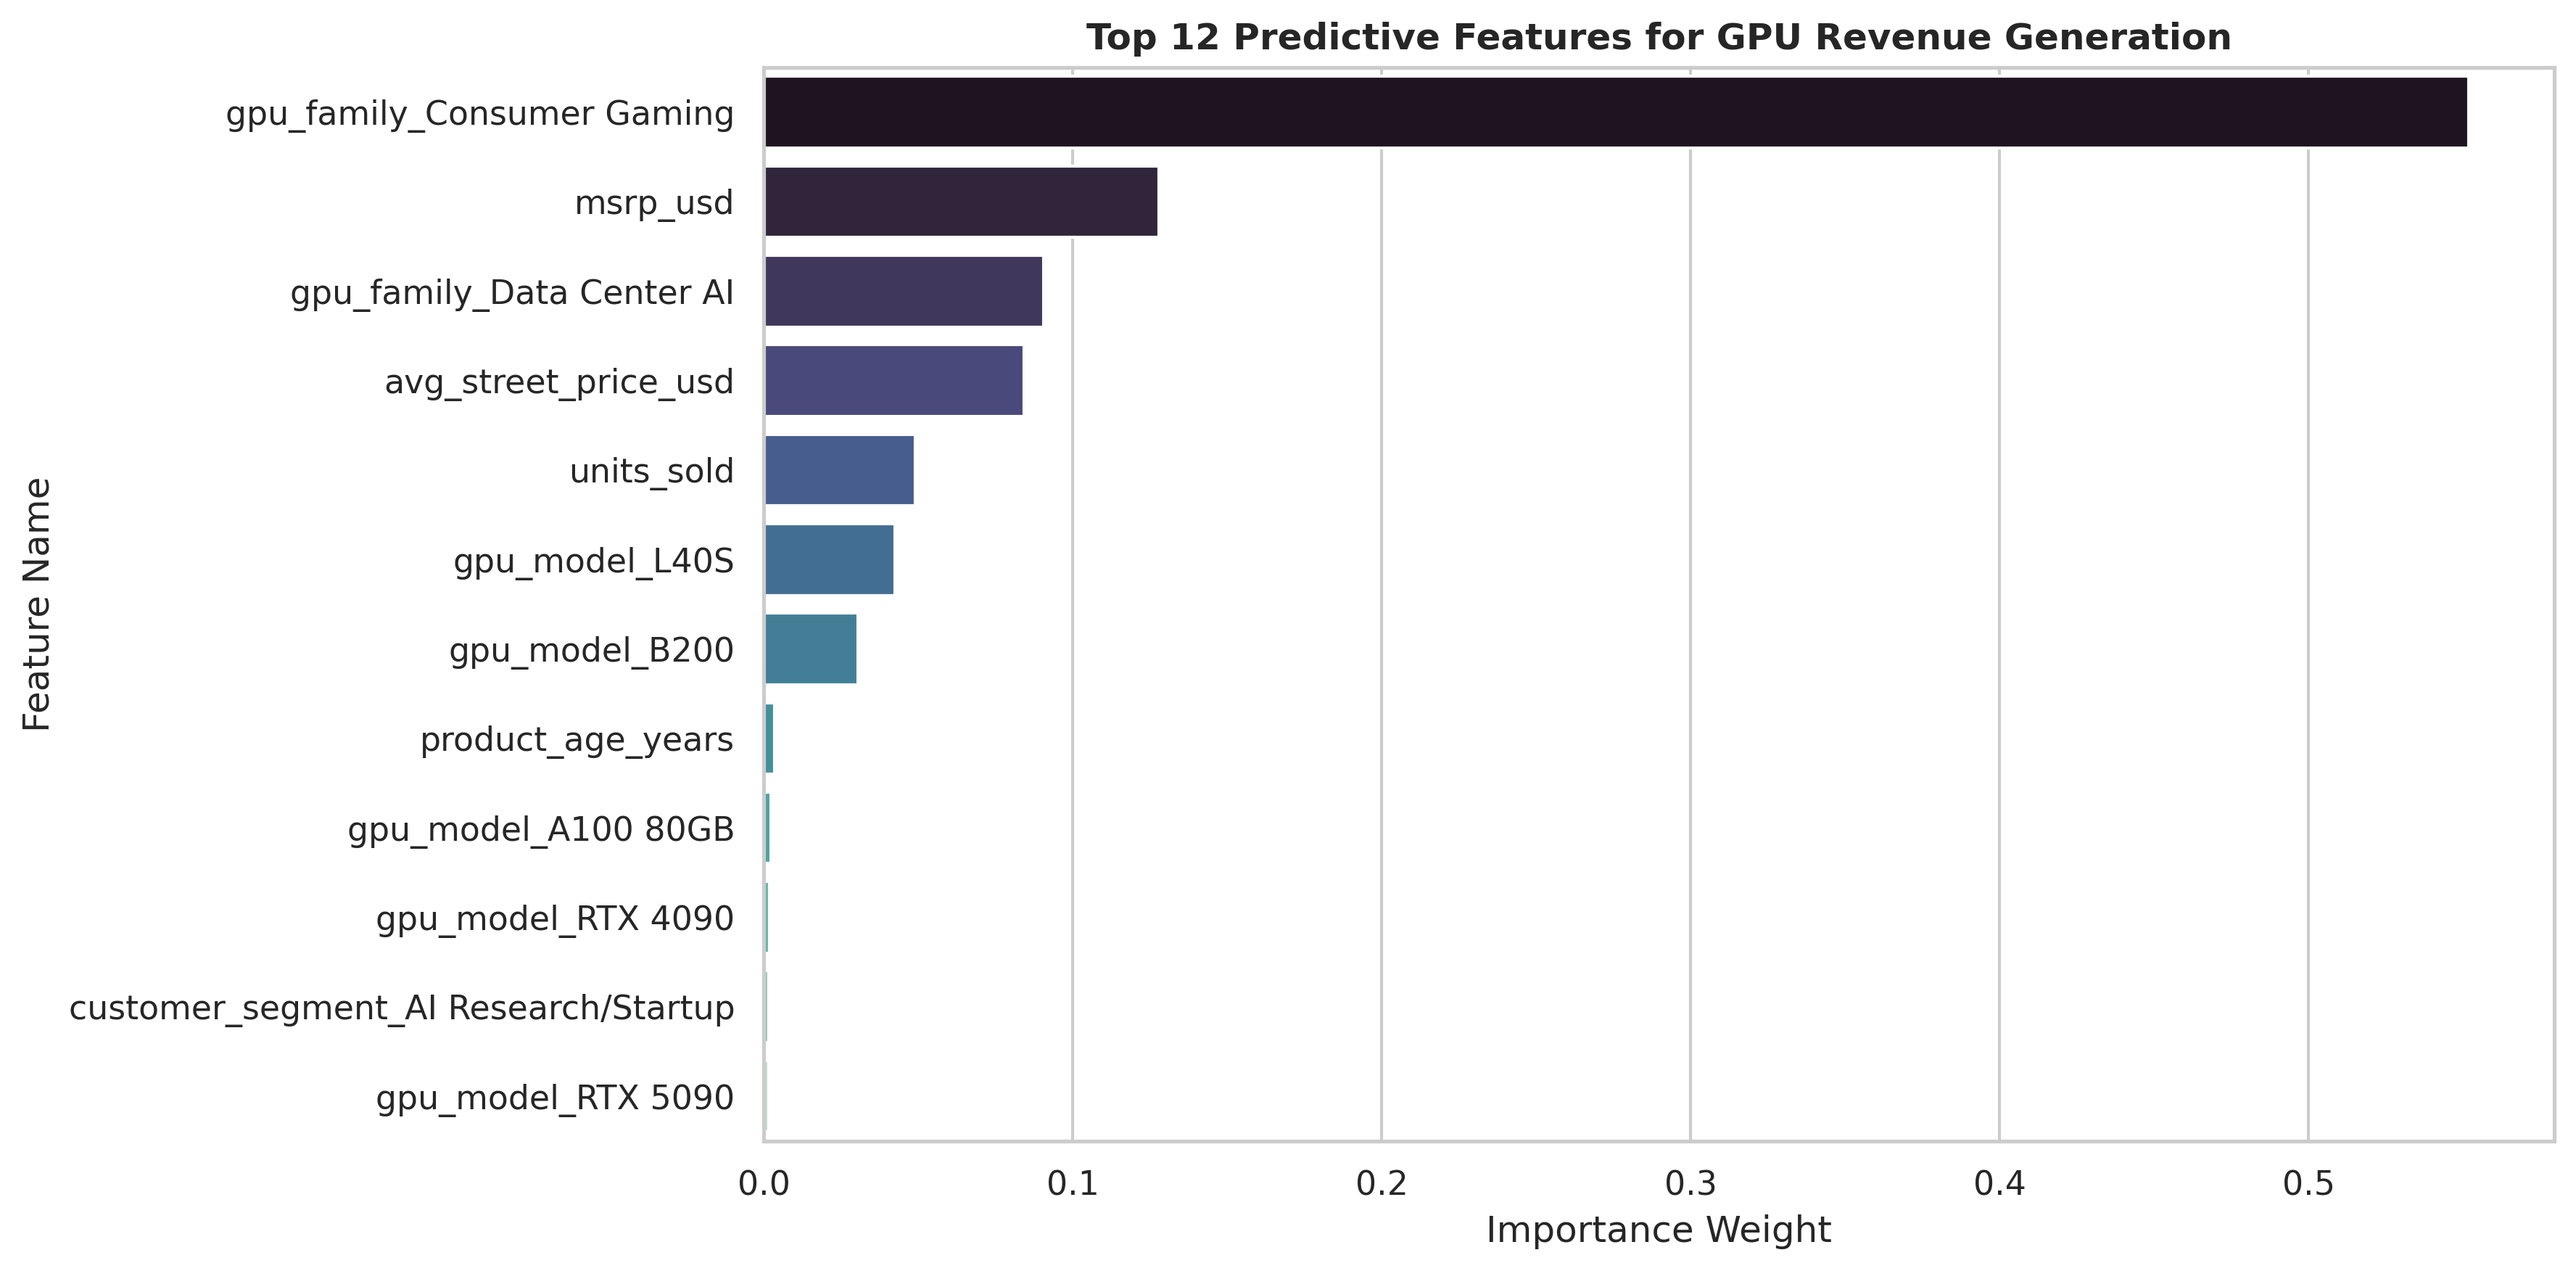

In [7]:
# Extract encoder feature names safely
cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
if len(cat_cols) > 0:
    encoded_cat_names = cat_encoder.get_feature_names_out(cat_cols).tolist()
else:
    encoded_cat_names = []

all_feature_names = num_cols + encoded_cat_names
xgb_model = model_pipeline.named_steps['regressor']
importances = xgb_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(12)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_imp_df, x='importance', y='feature', palette='mako')
plt.title('Top 12 Predictive Features for GPU Revenue Generation', fontweight='bold')
plt.xlabel('Importance Weight')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## 7. Strategic Business Takeaways

* **Inventory-Driven Premium Capture:** Transactions labeled as Low Stock exhibit high price_premium_pct spikes above MSRP. Implementing dynamic pricing algorithms on OEM channels can direct this margin to primary sales rather than third-party reseller markups.

* **Volume Scalability in Enterprise Channels:** System Integrator and Data Center contracts drive high bulk order sizes (units_sold), yielding predictable recurring revenue compared to retail channel fluctuations.

* **Product Lifecycle Dynamics:** Revenue sensitivity for enterprise cards decays slower over product_age_years relative to consumer GPUs, where bundling software accessories becomes necessary to maintain sales velocity post-launch.

## 8. Dashboard Data Preparation & Export

In [8]:
import glob

if 'df' not in locals() and 'df' not in globals():
    file_name = "nvidia_gpu_sales_synthetic_2026.csv"
    local_files = glob.glob(f"/kaggle/input/**/{file_name}", recursive=True) + glob.glob("/kaggle/input/**/*.csv", recursive=True)
    if local_files:
        df = pd.read_csv(local_files[0])
        df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
        df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
        df['revenue_usd'] = pd.to_numeric(df['revenue_usd'], errors='coerce').clip(lower=0)
        df['units_sold'] = pd.to_numeric(df['units_sold'], errors='coerce').fillna(1).astype(int)
        df['msrp_usd'] = pd.to_numeric(df['msrp_usd'], errors='coerce').fillna(0.0)
        df['price_premium_pct'] = pd.to_numeric(df['price_premium_pct'], errors='coerce').fillna(0.0)
    else:
        raise NameError("DataFrame 'df' is missing and dataset file was not found. Please re-run Sections 1 & 2 first.")

df['sale_year_month'] = df['sale_date'].dt.strftime('%Y-%m')
df['sale_quarter_label'] = df['sale_date'].dt.to_period('Q').astype(str)


df['realized_unit_price'] = np.where(df['units_sold'] > 0, df['revenue_usd'] / df['units_sold'], 0.0)


df['price_tier'] = pd.cut(
    df['msrp_usd'],
    bins=[-1, 500, 1200, 3000, np.inf],
    labels=['Budget (<$500)', 'Mid-Range ($500-$1200)', 'High-End ($1200-$3000)', 'Enterprise ($3000+)']
)

df['premium_category'] = np.where(
    df['price_premium_pct'] > 20, 'Extreme Premium (>20%)',
    np.where(
        df['price_premium_pct'] > 10, 'Moderate Premium (10-20%)',
        np.where(df['price_premium_pct'] > 0, 'Low Premium (0-10%)', 'At/Below MSRP')
    )
)

df['stock_risk_flag'] = np.where(df['stock_status'].isin(['Low Stock', 'Sold Out', 'Backordered']), 1, 0)

# File export
output_path = "nvidia_gpu_sales_dashboard_ready.csv"
df.to_csv(output_path, index=False)

print(f"Processed dataset successfully saved to: '{output_path}'")
print(f"Final Export Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Processed dataset successfully saved to: 'nvidia_gpu_sales_dashboard_ready.csv'
Final Export Shape: 7000 rows, 29 columns
